# Optimización de Campañas Publicitarias con Multi-Armed Bandits
### Un estudio comparativo: A/B Testing, ε-greedy, UCB1 y Thompson Sampling

**Objetivo:** comparar de forma rigurosa (mediante simulación Monte Carlo) el
rendimiento de cuatro estrategias de asignación de tráfico en un escenario de
marketing digital, donde varias creatividades de anuncio compiten por conversión.

**Pregunta de investigación:** ¿qué algoritmo minimiza el *regret* acumulado, y
cómo cambia el rendimiento relativo de cada uno según la dificultad del escenario
(diferencias entre tasas de conversión, número de brazos, horizonte temporal)?

**Metodología:** simulación de bandits Bernoulli sobre cuatro escenarios de
dificultad creciente (diferencias grandes vs. pequeñas entre tasas de conversión,
pocos vs. muchos brazos), con 500 repeticiones Monte Carlo por combinación
algoritmo-escenario para obtener resultados estadísticamente robustos.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from dataclasses import dataclass, field

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

### 1. Entorno de simulación: `BanditEnvironment`
Modelamos cada anuncio (brazo) como una variable de Bernoulli con una probabilidad de
conversión real `p_i`, desconocida para los algoritmos.

In [4]:
@dataclass
class BanditEnvironment:
    true_probs: list[float]

    def __post_init__(self):
        self.n_arms = len(self.true_probs)
        self.true_probs = np.array(self.true_probs)
        self.best_arm = np.argmax(self.true_probs)
        self.best_prob = self.true_probs[self.best_arm]

    def pull(self, arm_index: int) -> int:
        """Simula mostrar el anuncio `arm_index` a un usuario y devuelve 1 (conversión) o 0."""
        return int(np.random.rand() < self.true_probs[arm_index])

In [5]:
env_test = BanditEnvironment(true_probs=[0.05, 0.08, 0.03])

print(f"Número de brazos: {env_test.n_arms}")
print(f"Mejor brazo: {env_test.best_arm} (p = {env_test.best_prob})")
print(f"10 tiradas del brazo 1: {[env_test.pull(1) for _ in range(10)]}")

Número de brazos: 3
Mejor brazo: 1 (p = 0.08)
10 tiradas del brazo 1: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]


### 2. Escenarios predefinidos

Para poder comparar los algoritmos de forma rigurosa, definimos varios escenarios con
distinta dificultad: diferencias grandes vs. pequeñas entre las tasas de conversión de
los brazos, y pocos vs. muchos brazos. Los añadimos como `classmethod` de
`BanditEnvironment` para no tener que escribir las probabilidades a mano cada vez que
los usemos.

In [6]:
@dataclass
class BanditEnvironment:
    true_probs: list[float]

    def __post_init__(self):
        self.n_arms = len(self.true_probs)
        self.true_probs = np.array(self.true_probs)
        self.best_arm = np.argmax(self.true_probs)
        self.best_prob = self.true_probs[self.best_arm]

    def pull(self, arm_index: int) -> int:
        """Simula mostrar el anuncio `arm_index` a un usuario y devuelve 1 (conversión) o 0."""
        return int(np.random.rand() < self.true_probs[arm_index])

    @classmethod
    def escenario_facil(cls):
        """Diferencias grandes entre brazos"""
        return cls(true_probs=[0.02, 0.05, 0.1])

    @classmethod
    def escenario_dificil(cls):
        """Diferencias muy pequeñas entre brazos"""
        return cls(true_probs=[0.048, 0.050, 0.052])

    @classmethod
    def escenario_pocos_brazos(cls):
        """k=3, referencia base."""
        return cls(true_probs=[0.03, 0.05, 0.08])

    @classmethod
    def escenario_muchos_brazos(cls):
        """k=15, con un único brazo claramente mejor entre muchos mediocres."""
        rng = np.random.default_rng(7)
        probs = rng.uniform(0.02, 0.05, size=14).tolist()
        probs.append(0.09)  # el brazo ganador, al final de la lista
        return cls(true_probs=probs)

In [7]:
escenarios = {
    "Fácil": BanditEnvironment.escenario_facil(),
    "Difícil": BanditEnvironment.escenario_dificil(),
    "Pocos brazos": BanditEnvironment.escenario_pocos_brazos(),
    "Muchos brazos": BanditEnvironment.escenario_muchos_brazos(),
}

for nombre, env in escenarios.items():
    print(f"{nombre}: k={env.n_arms}, probs={env.true_probs.round(3)}, mejor brazo={env.best_arm} (p={env.best_prob:.3f})")

Fácil: k=3, probs=[0.02 0.05 0.1 ], mejor brazo=2 (p=0.100)
Difícil: k=3, probs=[0.048 0.05  0.052], mejor brazo=2 (p=0.052)
Pocos brazos: k=3, probs=[0.03 0.05 0.08], mejor brazo=2 (p=0.080)
Muchos brazos: k=15, probs=[0.039 0.047 0.043 0.027 0.029 0.046 0.02  0.045 0.044 0.034 0.029 0.028
 0.028 0.033 0.09 ], mejor brazo=14 (p=0.090)


### 3. Algoritmos de asignación de tráfico

Implementamos cuatro estrategias distintas para decidir, en cada ronda, qué brazo
mostrar. Cada una devuelve una secuencia de decisiones y resultados que luego usaremos
para calcular el regret acumulado y comparar objetivamente su rendimiento.

#### 3.1 A/B Testing tradicional

El enfoque "de manual": se reparte el tráfico a partes iguales entre todos los brazos
durante toda la duración del experimento (fase de exploración pura), y solo al final
se decide cuál es el ganador para explotarlo. No hay adaptación durante el proceso.

In [8]:
def run_ab_testing(env: BanditEnvironment, T: int, split_ratio: float = None):
    """
    Simula A/B testing tradicional: reparte el tráfico a partes iguales entre
    todos los brazos durante toda la duración T.
    
    Devuelve:
        chosen_arms: array de longitud T con el índice del brazo elegido en cada ronda
        rewards: array de longitud T con el resultado (0/1) obtenido en cada ronda
    """
    chosen_arms = np.zeros(T, dtype=int)
    rewards = np.zeros(T, dtype=int)

    for t in range(T):
        arm = t % env.n_arms  # reparto round-robin: 0,1,2,0,1,2,...
        reward = env.pull(arm)

        chosen_arms[t] = arm
        rewards[t] = reward

    return chosen_arms, rewards

In [9]:
env = BanditEnvironment.escenario_facil()
chosen, rewards = run_ab_testing(env, T=1000)

print(f"Total de conversiones obtenidas: {rewards.sum()} de {len(rewards)} rondas")
print(f"Tasa de conversión observada: {rewards.mean():.4f}")
print(f"Reparto de tráfico por brazo: {np.bincount(chosen)}")

Total de conversiones obtenidas: 53 de 1000 rondas
Tasa de conversión observada: 0.0530
Reparto de tráfico por brazo: [334 333 333]


#### 3.2 ε-greedy

En cada ronda, con probabilidad ε se elige un brazo al azar (exploración), y con
probabilidad 1-ε se elige el brazo con mejor tasa de conversión observada hasta el
momento (explotación). A diferencia de A/B testing, aquí sí hay adaptación: el
algoritmo va aprendiendo de los resultados según avanza el experimento.

In [10]:
def run_epsilon_greedy(env: BanditEnvironment, T: int, epsilon: float = 0.1):
    """
    Simula ε-greedy: con probabilidad epsilon elige un brazo al azar,
    con probabilidad 1-epsilon elige el brazo con mejor media observada.

    Devuelve:
        chosen_arms: array de longitud T con el índice del brazo elegido en cada ronda
        rewards: array de longitud T con el resultado (0/1) obtenido en cada ronda
    """
    chosen_arms = np.zeros(T, dtype=int)
    rewards = np.zeros(T, dtype=int)

    counts = np.zeros(env.n_arms)      # nº de veces que se ha probado cada brazo
    sums = np.zeros(env.n_arms)        # suma de recompensas obtenidas por cada brazo

    for t in range(T):
        if np.random.rand() < epsilon:
            arm = np.random.randint(env.n_arms)   # exploración: brazo al azar
        else:
            means = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
            arm = np.argmax(means)                 # explotación: mejor media hasta ahora

        reward = env.pull(arm)

        counts[arm] += 1
        sums[arm] += reward
        chosen_arms[t] = arm
        rewards[t] = reward

    return chosen_arms, rewards

In [11]:
env = BanditEnvironment.escenario_facil()
chosen, rewards = run_epsilon_greedy(env, T=1000, epsilon=0.1)

print(f"Total de conversiones obtenidas: {rewards.sum()} de {len(rewards)} rondas")
print(f"Tasa de conversión observada: {rewards.mean():.4f}")
print(f"Reparto de tráfico por brazo: {np.bincount(chosen, minlength=env.n_arms)}")
print(f"Mejor brazo real: {env.best_arm} — veces elegido: {np.bincount(chosen, minlength=env.n_arms)[env.best_arm]}")

Total de conversiones obtenidas: 79 de 1000 rondas
Tasa de conversión observada: 0.0790
Reparto de tráfico por brazo: [ 67 406 527]
Mejor brazo real: 2 — veces elegido: 527


#### 3.3 Upper Confidence Bound (UCB1)

En vez de elegir siempre el brazo con mejor media observada, UCB1 elige el brazo con
mayor **límite superior de confianza**: media observada + un término de incertidumbre
que crece cuanto menos se ha probado ese brazo. Así, los brazos poco explorados se
"empujan" hacia arriba automáticamente, sin necesidad de un parámetro aleatorio como
epsilon.

Fórmula para el brazo *i* en la ronda *t*:

$$UCB_i = \bar{x}_i + \sqrt{\frac{2 \ln t}{n_i}}$$

donde $\bar{x}_i$ es la media observada del brazo *i*, y $n_i$ el número de veces que
se ha probado.

In [12]:
def run_ucb1(env: BanditEnvironment, T: int):
    """
    Simula UCB1: elige en cada ronda el brazo con mayor límite superior de confianza
    (media observada + término de incertidumbre).

    Devuelve:
        chosen_arms: array de longitud T con el índice del brazo elegido en cada ronda
        rewards: array de longitud T con el resultado (0/1) obtenido en cada ronda
    """
    chosen_arms = np.zeros(T, dtype=int)
    rewards = np.zeros(T, dtype=int)

    counts = np.zeros(env.n_arms)
    sums = np.zeros(env.n_arms)

    for t in range(T):
        if t < env.n_arms:
            arm = t  # fase inicial obligatoria: probar cada brazo una vez
        else:
            means = sums / counts
            bonus = np.sqrt(2 * np.log(t) / counts)
            ucb_values = means + bonus
            arm = np.argmax(ucb_values)

        reward = env.pull(arm)

        counts[arm] += 1
        sums[arm] += reward
        chosen_arms[t] = arm
        rewards[t] = reward

    return chosen_arms, rewards

In [13]:
env = BanditEnvironment.escenario_facil()
chosen, rewards = run_ucb1(env, T=1000)

print(f"Total de conversiones obtenidas: {rewards.sum()} de {len(rewards)} rondas")
print(f"Tasa de conversión observada: {rewards.mean():.4f}")
print(f"Reparto de tráfico por brazo: {np.bincount(chosen, minlength=env.n_arms)}")
print(f"Mejor brazo real: {env.best_arm} — veces elegido: {np.bincount(chosen, minlength=env.n_arms)[env.best_arm]}")

Total de conversiones obtenidas: 66 de 1000 rondas
Tasa de conversión observada: 0.0660
Reparto de tráfico por brazo: [256 343 401]
Mejor brazo real: 2 — veces elegido: 401


#### 3.4 Thompson Sampling

Enfoque bayesiano: en vez de una única estimación puntual (como la media en ε-greedy
o UCB1), mantenemos una **distribución de probabilidad** sobre la tasa de conversión
real de cada brazo. Empezamos sin saber nada (distribución uniforme) y la vamos
actualizando con cada resultado observado. En cada ronda, "muestreamos" un valor de
cada distribución y elegimos el brazo con el valor muestreado más alto.

Para recompensas binarias (conversión/no conversión), la distribución natural es la
**Beta**, porque es el conjugado de la Bernoulli: al observar un éxito, el parámetro
α (alpha) sube en 1; al observar un fracaso, el parámetro β (beta) sube en 1. Así de
simple es actualizar la creencia.

$$\text{Beta}(\alpha=1, \beta=1) \text{ (creencia inicial, uniforme)} \rightarrow \text{Beta}(\alpha + \text{éxitos}, \ \beta + \text{fracasos})$$

In [14]:
def run_thompson_sampling(env: BanditEnvironment, T: int):
    """
    Simula Thompson Sampling: mantiene una distribución Beta(alpha, beta) por brazo,
    muestrea un valor de cada una en cada ronda, y elige el brazo con el muestreo más alto.

    Devuelve:
        chosen_arms: array de longitud T con el índice del brazo elegido en cada ronda
        rewards: array de longitud T con el resultado (0/1) obtenido en cada ronda
    """
    chosen_arms = np.zeros(T, dtype=int)
    rewards = np.zeros(T, dtype=int)

    alpha = np.ones(env.n_arms)   # empieza en 1 para cada brazo (Beta(1,1) = uniforme)
    beta = np.ones(env.n_arms)    # empieza en 1 para cada brazo

    for t in range(T):
        samples = np.random.beta(alpha, beta)   # un muestreo por brazo
        arm = np.argmax(samples)

        reward = env.pull(arm)

        if reward == 1:
            alpha[arm] += 1
        else:
            beta[arm] += 1

        chosen_arms[t] = arm
        rewards[t] = reward

    return chosen_arms, rewards

In [15]:
env = BanditEnvironment.escenario_facil()
chosen, rewards = run_thompson_sampling(env, T=1000)

print(f"Total de conversiones obtenidas: {rewards.sum()} de {len(rewards)} rondas")
print(f"Tasa de conversión observada: {rewards.mean():.4f}")
print(f"Reparto de tráfico por brazo: {np.bincount(chosen, minlength=env.n_arms)}")
print(f"Mejor brazo real: {env.best_arm} — veces elegido: {np.bincount(chosen, minlength=env.n_arms)[env.best_arm]}")

Total de conversiones obtenidas: 87 de 1000 rondas
Tasa de conversión observada: 0.0870
Reparto de tráfico por brazo: [ 85 138 777]
Mejor brazo real: 2 — veces elegido: 777


### 4. Métrica de evaluación: Regret acumulado

El **regret** en la ronda *t* mide cuánto "perdiste" por no haber elegido el mejor
brazo posible en esa ronda: la diferencia entre la probabilidad de conversión del
mejor brazo real y la probabilidad del brazo que el algoritmo eligió.

$$\text{regret}_t = p_{\text{óptimo}} - p_{\text{brazo elegido en } t}$$

Sumando el regret de todas las rondas obtenemos el **regret acumulado**, que es la
curva que usaremos para comparar algoritmos: cuanto más plana (menos creciente), mejor
está funcionando el algoritmo.

In [16]:
def calculate_regret(env: BanditEnvironment, chosen_arms: np.ndarray) -> np.ndarray:
    """
    Calcula el regret acumulado a partir de la secuencia de brazos elegidos.

    Devuelve:
        cumulative_regret: array de longitud T con el regret acumulado hasta cada ronda
    """
    expected_rewards = env.true_probs[chosen_arms]
    regret_per_round = env.best_prob - expected_rewards
    cumulative_regret = np.cumsum(regret_per_round)
    return cumulative_regret

In [17]:
env = BanditEnvironment.escenario_facil()
chosen, rewards = run_thompson_sampling(env, T=1000)
regret = calculate_regret(env, chosen)

print(f"Regret acumulado final: {regret[-1]:.2f}")
print(f"Regret en la ronda 10: {regret[9]:.4f}")
print(f"Regret en la ronda 1000: {regret[-1]:.4f}")

Regret acumulado final: 10.58
Regret en la ronda 10: 0.4900
Regret en la ronda 1000: 10.5800


### 5. Simulación Monte Carlo

Una sola corrida de un algoritmo no es suficiente para sacar conclusiones: el
resultado depende en parte de la suerte en esa tirada concreta. Repetimos cada
combinación (algoritmo, escenario) un número grande de veces (n_runs) y promediamos
el regret acumulado a lo largo de todas las repeticiones, guardando también la
variabilidad (para poder dibujar bandas de confianza más adelante).

In [18]:
ALGORITHMS = {
    "A/B Testing": run_ab_testing,
    "ε-greedy": run_epsilon_greedy,
    "UCB1": run_ucb1,
    "Thompson Sampling": run_thompson_sampling,
}

def run_monte_carlo(algorithm_fn, env_factory, T: int, n_runs: int = 500) -> np.ndarray:
    """
    Ejecuta `algorithm_fn` n_runs veces sobre un entorno recreado en cada repetición,
    y devuelve la matriz de regret acumulado de todas las corridas.

    Parámetros:
        algorithm_fn: una de las funciones run_ab_testing, run_epsilon_greedy, etc.
        env_factory: función sin argumentos que devuelve un BanditEnvironment nuevo
                     (ej. BanditEnvironment.escenario_facil)
        T: horizonte temporal de cada corrida
        n_runs: número de repeticiones Monte Carlo

    Devuelve:
        all_regrets: array de forma (n_runs, T) — una fila de regret acumulado por corrida
    """
    all_regrets = np.zeros((n_runs, T))

    for run in range(n_runs):
        env = env_factory()
        chosen_arms, _ = algorithm_fn(env, T)
        all_regrets[run] = calculate_regret(env, chosen_arms)

    return all_regrets

In [19]:
regrets_ts = run_monte_carlo(
    algorithm_fn=run_thompson_sampling,
    env_factory=BanditEnvironment.escenario_facil,
    T=1000,
    n_runs=500,
)

print(f"Forma de la matriz de resultados: {regrets_ts.shape}")
print(f"Regret medio final (ronda 1000): {regrets_ts[:, -1].mean():.2f}")
print(f"Desviación estándar del regret final: {regrets_ts[:, -1].std():.2f}")

Forma de la matriz de resultados: (500, 1000)
Regret medio final (ronda 1000): 11.89
Desviación estándar del regret final: 5.42


### 6. Ejecución completa: los 4 algoritmos × los 4 escenarios

Corremos Monte Carlo para cada combinación de algoritmo y escenario, y guardamos
todos los resultados en un único diccionario anidado que usaremos como base para
todas las gráficas y tablas del análisis.

In [20]:
SCENARIOS = {
    "Fácil": BanditEnvironment.escenario_facil,
    "Difícil": BanditEnvironment.escenario_dificil,
    "Pocos brazos": BanditEnvironment.escenario_pocos_brazos,
    "Muchos brazos": BanditEnvironment.escenario_muchos_brazos,
}

T = 5000
N_RUNS = 500

results = {}  # results[nombre_escenario][nombre_algoritmo] = matriz (n_runs, T)

for scenario_name, scenario_factory in SCENARIOS.items():
    results[scenario_name] = {}
    for algo_name, algo_fn in ALGORITHMS.items():
        print(f"Corriendo {algo_name} en escenario '{scenario_name}'...")
        results[scenario_name][algo_name] = run_monte_carlo(
            algorithm_fn=algo_fn,
            env_factory=scenario_factory,
            T=T,
            n_runs=N_RUNS,
        )

print("\n¡Listo! Todas las combinaciones simuladas.")

Corriendo A/B Testing en escenario 'Fácil'...
Corriendo ε-greedy en escenario 'Fácil'...
Corriendo UCB1 en escenario 'Fácil'...
Corriendo Thompson Sampling en escenario 'Fácil'...
Corriendo A/B Testing en escenario 'Difícil'...
Corriendo ε-greedy en escenario 'Difícil'...
Corriendo UCB1 en escenario 'Difícil'...
Corriendo Thompson Sampling en escenario 'Difícil'...
Corriendo A/B Testing en escenario 'Pocos brazos'...
Corriendo ε-greedy en escenario 'Pocos brazos'...
Corriendo UCB1 en escenario 'Pocos brazos'...
Corriendo Thompson Sampling en escenario 'Pocos brazos'...
Corriendo A/B Testing en escenario 'Muchos brazos'...
Corriendo ε-greedy en escenario 'Muchos brazos'...
Corriendo UCB1 en escenario 'Muchos brazos'...
Corriendo Thompson Sampling en escenario 'Muchos brazos'...

¡Listo! Todas las combinaciones simuladas.


In [28]:
import pickle

with open("bandit_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("Resultados guardados en bandit_results.pkl")

Resultados guardados en bandit_results.pkl


### 7. Curvas de regret acumulado

Para cada escenario, dibujamos la evolución del regret acumulado medio de los 4
algoritmos a lo largo de las 5000 rondas, con una banda que representa la
variabilidad entre las 500 repeticiones Monte Carlo. Una curva más plana (con
pendiente que decrece con el tiempo) indica un algoritmo que converge mejor hacia
el brazo óptimo.

In [21]:
def plot_regret_scenario(scenario_name: str, ax=None):
    """
    Dibuja las curvas de regret acumulado (media ± desviación estándar) de los
    4 algoritmos para un escenario dado.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))

    x = np.arange(T)

    for algo_name in ALGORITHMS:
        regrets = results[scenario_name][algo_name]   # matriz (n_runs, T)
        mean_regret = regrets.mean(axis=0)             # media por ronda, across corridas
        std_regret = regrets.std(axis=0)                # desviación estándar por ronda

        ax.plot(x, mean_regret, label=algo_name)
        ax.fill_between(x, mean_regret - std_regret, mean_regret + std_regret, alpha=0.15)

    ax.set_xlabel("Ronda (t)")
    ax.set_ylabel("Regret acumulado")
    ax.set_title(f"Escenario: {scenario_name}")
    ax.legend()
    return ax

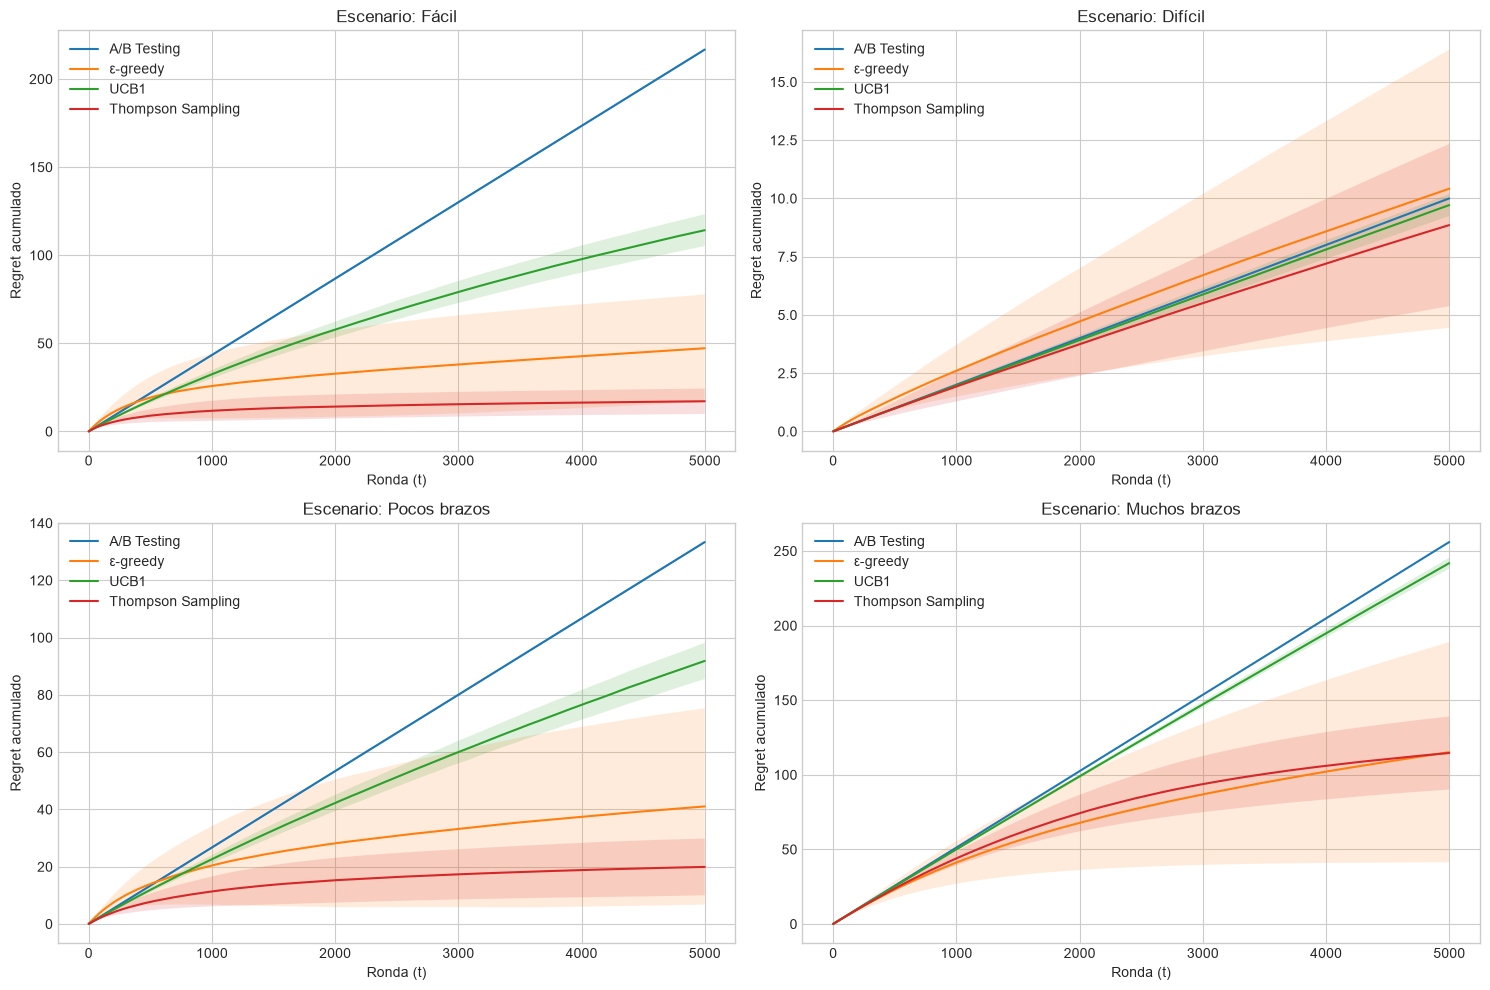

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, scenario_name in zip(axes, SCENARIOS.keys()):
    plot_regret_scenario(scenario_name, ax=ax)

plt.tight_layout()
plt.show()

### 8. Tabla resumen: regret final por algoritmo y escenario

Para poder afirmar con precisión qué algoritmo rinde mejor en cada escenario, 
construimos una tabla con el regret acumulado medio al
final del horizonte (ronda 5000), junto a su desviación estándar, para las 16
combinaciones simuladas.

In [23]:
import pandas as pd

summary_rows = []

for scenario_name in SCENARIOS:
    for algo_name in ALGORITHMS:
        final_regrets = results[scenario_name][algo_name][:, -1]  # última columna: ronda T-1
        summary_rows.append({
            "Escenario": scenario_name,
            "Algoritmo": algo_name,
            "Regret medio": final_regrets.mean(),
            "Desv. estándar": final_regrets.std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df["Regret medio"] = summary_df["Regret medio"].round(2)
summary_df["Desv. estándar"] = summary_df["Desv. estándar"].round(2)

summary_pivot = summary_df.pivot(index="Algoritmo", columns="Escenario", values="Regret medio")
summary_pivot = summary_pivot[["Fácil", "Difícil", "Pocos brazos", "Muchos brazos"]]  # reordenar columnas

summary_pivot

Escenario,Fácil,Difícil,Pocos brazos,Muchos brazos
Algoritmo,,,,
A/B Testing,216.71,10.00,133.36,255.98
Thompson Sampling,17.13,8.86,19.91,114.59
UCB1,114.18,9.71,91.85,241.86
ε-greedy,47.20,10.42,41.03,115.17


In [24]:
def formatear_media_std(row):
    return f"{row['Regret medio']:.1f} ± {row['Desv. estándar']:.1f}"

summary_df["Media ± Std"] = summary_df.apply(formatear_media_std, axis=1)
summary_pivot_completo = summary_df.pivot(index="Algoritmo", columns="Escenario", values="Media ± Std")
summary_pivot_completo = summary_pivot_completo[["Fácil", "Difícil", "Pocos brazos", "Muchos brazos"]]

summary_pivot_completo

Escenario,Fácil,Difícil,Pocos brazos,Muchos brazos
Algoritmo,,,,
A/B Testing,216.7 ± 0.0,10.0 ± 0.0,133.4 ± 0.0,256.0 ± 0.0
Thompson Sampling,17.1 ± 7.2,8.9 ± 3.5,19.9 ± 9.9,114.6 ± 24.5
UCB1,114.2 ± 9.0,9.7 ± 0.5,91.8 ± 6.3,241.9 ± 3.6
ε-greedy,47.2 ± 30.5,10.4 ± 6.0,41.0 ± 34.3,115.2 ± 73.8


### 9. Significancia estadística: ¿las diferencias son reales?

Una media más baja no implica necesariamente una diferencia real, puede deberse al
azar de la simulación Monte Carlo. Aplicamos un test t de Welch (que no asume
varianzas iguales entre grupos, apropiado aquí dado lo distintas que son las
desviaciones estándar observadas) a cada par de algoritmos, en cada escenario.

Usamos un umbral de significancia de α = 0.05, con corrección de Bonferroni para
tener en cuenta que hacemos múltiples comparaciones (6 pares × 4 escenarios = 24
tests), lo cual reduce el riesgo de encontrar "falsos positivos" solo por probar
muchas combinaciones.

In [25]:
from itertools import combinations

algo_names = list(ALGORITHMS.keys())
pairs = list(combinations(algo_names, 2))  # las 6 combinaciones posibles de 2 algoritmos

n_tests = len(pairs) * len(SCENARIOS)
alpha_corregido = 0.05 / n_tests  # corrección de Bonferroni

test_rows = []

for scenario_name in SCENARIOS:
    for algo_a, algo_b in pairs:
        regret_a = results[scenario_name][algo_a][:, -1]
        regret_b = results[scenario_name][algo_b][:, -1]

        t_stat, p_value = stats.ttest_ind(regret_a, regret_b, equal_var=False)

        test_rows.append({
            "Escenario": scenario_name,
            "Comparación": f"{algo_a} vs {algo_b}",
            "p-valor": p_value,
            "¿Significativo?": "Sí" if p_value < alpha_corregido else "No",
        })

test_df = pd.DataFrame(test_rows)
test_df["p-valor"] = test_df["p-valor"].apply(lambda p: f"{p:.4f}" if p >= 0.0001 else "<0.0001")

print(f"Umbral corregido (Bonferroni): α = {alpha_corregido:.5f}\n")
test_df

Umbral corregido (Bonferroni): α = 0.00208



c:\Users\34601\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Escenario,Comparación,p-valor,¿Significativo?
0,Fácil,A/B Testing vs ε-greedy,<0.0001,Sí
1,Fácil,A/B Testing vs UCB1,<0.0001,Sí
2,Fácil,A/B Testing vs Thompson Sampling,<0.0001,Sí
3,Fácil,ε-greedy vs UCB1,<0.0001,Sí
4,Fácil,ε-greedy vs Thompson Sampling,<0.0001,Sí
5,Fácil,UCB1 vs Thompson Sampling,<0.0001,Sí
6,Difícil,A/B Testing vs ε-greedy,0.1202,No
7,Difícil,A/B Testing vs UCB1,<0.0001,Sí
8,Difícil,A/B Testing vs Thompson Sampling,<0.0001,Sí
9,Difícil,ε-greedy vs UCB1,0.0089,No


### 10. Velocidad de convergencia

Definimos la velocidad de convergencia como el **porcentaje de corridas Monte Carlo
que eligieron el brazo óptimo en cada ronda t**. Un algoritmo que converge rápido
alcanza un porcentaje alto (ej. 95%) en pocas rondas; uno lento tarda mucho más, o
no llega a estabilizarse dentro del horizonte simulado.

Esta métrica se puede derivar directamente de las matrices de regret ya calculadas,
sin necesidad de volver a simular: si el regret de una ronda concreta es exactamente
0, es porque en esa ronda se eligió el brazo óptimo (ya que regret = p_óptimo - p_elegido,
y esa diferencia solo es 0 cuando el brazo elegido es el óptimo).

In [26]:
def calculate_optimal_rate(cumulative_regret_matrix: np.ndarray) -> np.ndarray:
    """
    A partir de una matriz de regret ACUMULADO (n_runs, T), calcula el porcentaje
    de corridas que eligieron el brazo óptimo en cada ronda t.

    Devuelve:
        optimal_rate: array de longitud T, con valores entre 0 y 1
    """
    # "deshacemos" el cumsum para recuperar el regret de cada ronda individual
    regret_per_round = np.diff(cumulative_regret_matrix, axis=1, prepend=0)

    # regret_per_round == 0  ->  en esa ronda se eligió el brazo óptimo
    optimal_choice = (regret_per_round == 0)

    # promediamos a través de las corridas (axis=0): % de corridas que acertaron en cada ronda
    optimal_rate = optimal_choice.mean(axis=0)
    return optimal_rate

In [30]:
optimal_rates = {}

for scenario_name in SCENARIOS:
    optimal_rates[scenario_name] = {}
    for algo_name in ALGORITHMS:
        optimal_rates[scenario_name][algo_name] = calculate_optimal_rate(
            results[scenario_name][algo_name]
        )

print("optimal_rates calculado para los 4 algoritmos.")

optimal_rates calculado para los 4 algoritmos.


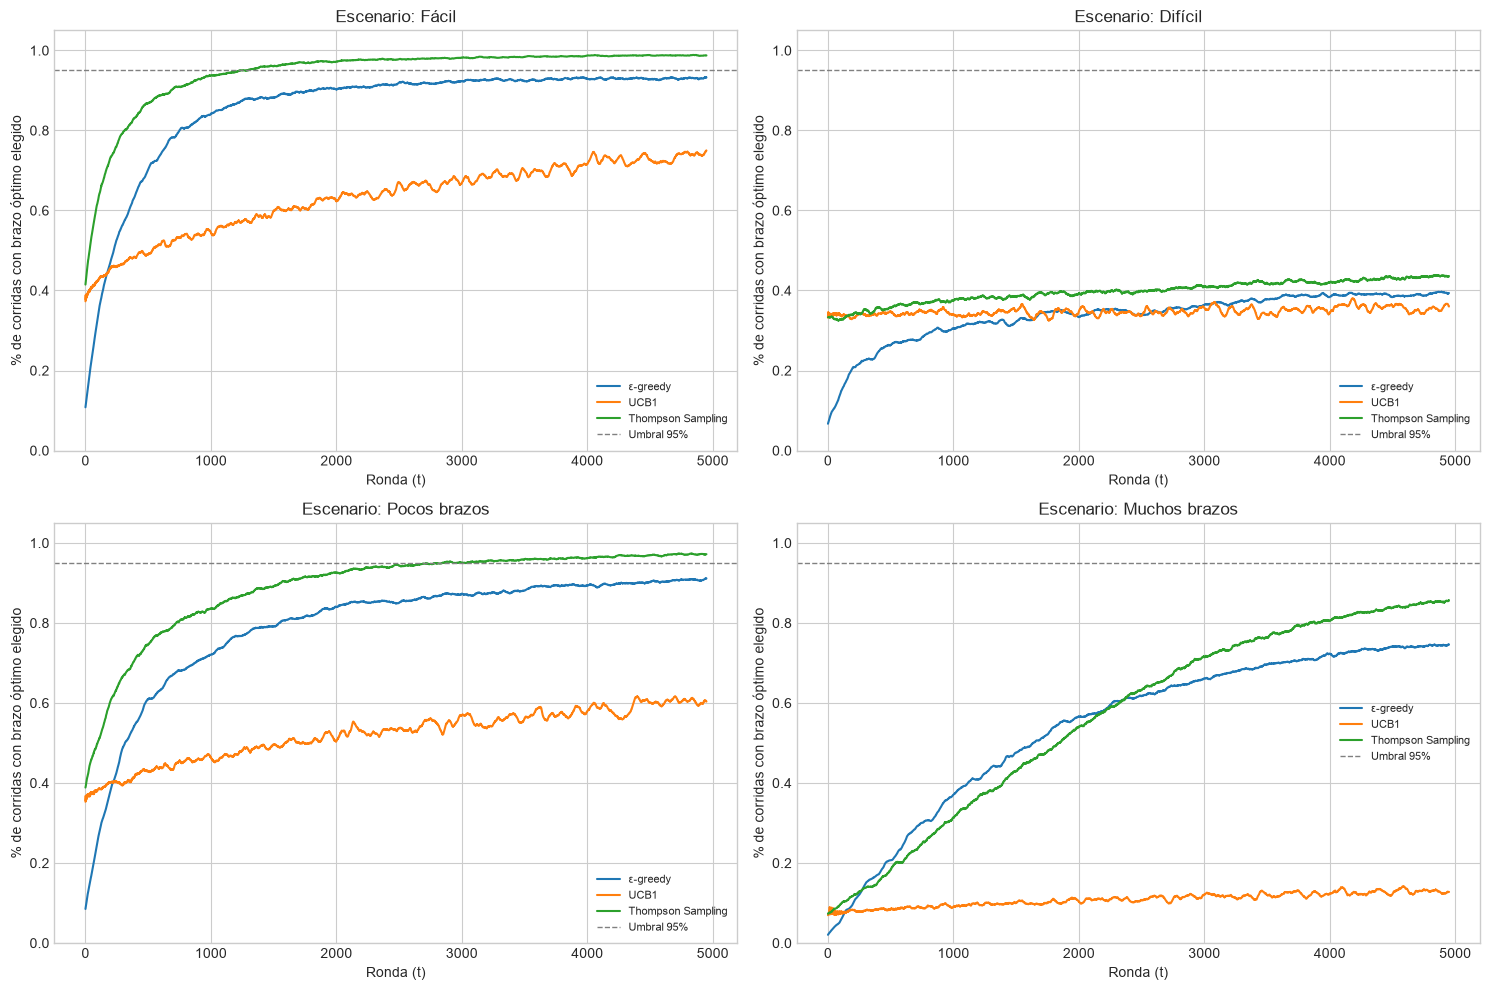

In [36]:
ALGORITHMS_ADAPTATIVOS = {k: v for k, v in ALGORITHMS.items() if k != "A/B Testing"}

def suavizar(serie: np.ndarray, ventana: int = 50) -> np.ndarray:
    """Aplica una media móvil de tamaño `ventana` para suavizar una curva ruidosa."""
    kernel = np.ones(ventana) / ventana
    return np.convolve(serie, kernel, mode="valid")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, scenario_name in zip(axes, SCENARIOS.keys()):
    for algo_name in ALGORITHMS_ADAPTATIVOS:
        rate_suavizado = suavizar(optimal_rates[scenario_name][algo_name])
        x = np.arange(len(rate_suavizado))
        ax.plot(x, rate_suavizado, label=algo_name)
    ax.axhline(0.95, color="gray", linestyle="--", linewidth=1, label="Umbral 95%")
    ax.set_xlabel("Ronda (t)")
    ax.set_ylabel("% de corridas con brazo óptimo elegido")
    ax.set_title(f"Escenario: {scenario_name}")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [38]:
def ronda_convergencia(optimal_rate: np.ndarray, umbral: float = 0.95, ventana: int = 200) -> str:
    """
    Devuelve la primera ronda t tal que optimal_rate se mantiene, en promedio,
    por encima del umbral durante las siguientes `ventana` rondas. Esto evita tanto
    falsos positivos por picos puntuales (ej. fase de calentamiento de UCB1) como
    falsos negativos por ruido residual normal de Monte Carlo.
    """
    T_local = len(optimal_rate)

    for t in range(T_local - ventana):
        if optimal_rate[t:t + ventana].mean() >= umbral:
            return str(t)

    return "No alcanzado"


convergencia_rows = []
for scenario_name in SCENARIOS:
    for algo_name in ALGORITHMS_ADAPTATIVOS:
        convergencia_rows.append({
            "Escenario": scenario_name,
            "Algoritmo": algo_name,
            "Ronda de convergencia (95%)": ronda_convergencia(optimal_rates[scenario_name][algo_name]),
        })

convergencia_df = pd.DataFrame(convergencia_rows)
convergencia_pivot = convergencia_df.pivot(index="Algoritmo", columns="Escenario", values="Ronda de convergencia (95%)")
convergencia_pivot = convergencia_pivot[["Fácil", "Difícil", "Pocos brazos", "Muchos brazos"]]

convergencia_pivot

Escenario,Fácil,Difícil,Pocos brazos,Muchos brazos
Algoritmo,,,,
Thompson Sampling,1191,No alcanzado,2748,No alcanzado
UCB1,No alcanzado,No alcanzado,No alcanzado,No alcanzado
ε-greedy,No alcanzado,No alcanzado,No alcanzado,No alcanzado


### 11. Conclusiones

#### Resumen de resultados por escenario

**Escenario Fácil y Pocos brazos** (diferencias grandes entre tasas de conversión):
Thompson Sampling obtiene el menor regret acumulado de forma estadísticamente
significativa frente a los otros tres algoritmos (p < 0.0001 en todas las
comparaciones). Además, es el único que alcanza una convergencia sostenida por
encima del 95% dentro del horizonte simulado (ronda 1191 en Fácil, 2748 en Pocos
brazos). UCB1, pese a sus garantías teóricas, rinde sorprendentemente mal en este
horizonte temporal, su término de exploración `√(2·ln(t)/n)` es más conservador de
lo que la intuición sugiere, y tarda en asentarse incluso cuando los brazos son
fácilmente distinguibles.

**Escenario Difícil** (diferencias de solo 0.2 puntos porcentuales entre brazos):
aquí es donde el rigor estadístico marcó la diferencia entre lo que parecía a simple vista
en las gráficas y lo que los datos realmente sostienen. Thompson Sampling tiene la
media de regret más baja y es estadísticamente distinto de los otros tres
(p < 0.0001), pero **A/B testing, ε-greedy y UCB1 no son distinguibles entre sí**
con la evidencia disponible (p = 0.12 y p = 0.009, por encima del umbral corregido
de Bonferroni). Ningún algoritmo alcanza convergencia sostenida al 95% en este
escenario, con gaps tan pequeños, 5000 rondas no bastan para que el ruido deje de
dominar sobre la señal.

**Escenario Muchos brazos** (15 brazos, uno claramente superior entre catorce
mediocres): el hallazgo más importante de todo el proyecto. **Thompson Sampling y ε-greedy
no muestran diferencia estadísticamente significativa en el regret medio final**
(p = 0.87). La ventaja real de Thompson Sampling aquí no está en la media, sino en
la **consistencia**: su desviación estándar (24.5) es un tercio de la de ε-greedy
(73.8). En términos de negocio, esto importa: dos algoritmos con el mismo
rendimiento esperado no son intercambiables si uno es mucho más predecible que el
otro campaña a campaña.

#### Hallazgos interesantes e inesperados

- **UCB1 no domina en ningún escenario del proyecto**, a pesar de ser el algoritmo
  con garantías teóricas más "limpias" en la literatura. Es el más estable en el
  escenario Difícil (desviación estándar de solo 0.5), pero eso no basta para
  compensar su lentitud en escenarios donde el gap entre brazos es mayor.
- **ε-greedy con epsilon fijo (0.1) nunca converge en sentido estricto**: al
  explorar aleatoriamente un 10% de las rondas de forma constante, su tasa de
  acierto se estabiliza por debajo del 95% en los cuatro escenarios, por diseño,
  no es una limitación del horizonte simulado, sino una consecuencia matemática de
  no usar una variante de epsilon decreciente.
- **A/B testing tiene varianza prácticamente nula** entre corridas Monte Carlo,
  porque su secuencia de decisiones es determinista (round-robin) y no se adapta a
  los resultados observados. Esto lo hace completamente predecible, pero a costa de
  un regret sistemáticamente más alto que cualquier alternativa adaptativa en los
  cuatro escenarios.
- **Significancia estadística no es lo mismo que relevancia práctica**: en el
  escenario Difícil, UCB1 vs A/B testing salió estadísticamente significativo
  (p < 0.0001) a pesar de que sus medias son casi idénticas (9.7 vs 10.0), el
  resultado se debe a la varianza casi nula de UCB1, no a una diferencia que
  importe en términos de negocio.

#### Recomendación

No hay un algoritmo que gane en los cuatro escenarios de forma universal, pero el
patrón general favorece a Thompson Sampling: iguala o supera a las alternativas en
regret medio en los cuatro escenarios, y cuando empata en media (Muchos brazos) lo
hace con menor varianza, una propiedad valiosa en un contexto real de campaña
publicitaria, donde la previsibilidad del resultado tiene valor en sí misma. UCB1
solo se recomendaría en contextos donde la estabilidad importe más que la velocidad
de aprendizaje. ε-greedy con epsilon fijo no se recomienda salvo como baseline
simple; una variante con epsilon decreciente probablemente cerraría buena parte de
la distancia frente a Thompson Sampling sin su desventaja de exploración perpetua.

#### Limitaciones y extensiones futuras

- Solo se probó ε-greedy con un valor fijo de epsilon (0.1); un análisis de
  sensibilidad sobre distintos valores, o una variante con annealing, quedaría
  pendiente.
- El escenario Difícil sugiere que 5000 rondas pueden no ser suficientes cuando los
  gaps entre brazos son muy pequeños. Probar horizontes más largos (T=20,000 o
  más) permitiría ver si Thompson Sampling termina separándose con más claridad, o
  si el problema sigue siendo indistinguible incluso a largo plazo.
- El proyecto usa bandits "estacionarios" (las probabilidades reales no cambian
  durante el experimento). En marketing digital real, el CTR de un anuncio puede
  degradarse con el tiempo (fatiga publicitaria), extender el proyecto a un
  entorno no estacionario sería un paso natural siguiente.
- No se implementaron bandits contextuales (LinUCB, Thompson Sampling contextual),
  que incorporarían información del usuario (dispositivo, hora del día, historial)
  en la decisión, mencionados en el planteamiento inicial como posible puente
  hacia sistemas de recomendación más sofisticados.